# KDD Data Analysis and Attack Classification using Machine Learning & Neural Networks
This notebook covers data preprocessing, feature engineering, and training multiple ML models to classify attacks using the KDD dataset.

In [9]:
import pandas as pd  # Importing pandas for data handling
import numpy as np  # Importing numpy for numerical operations
import seaborn as sns  # Importing seaborn for visualization
import matplotlib.pyplot as plt  # Importing matplotlib for plotting graphs
from sklearn.model_selection import train_test_split  # Splitting dataset into train and test
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Encoding categorical variables and scaling data
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Importing classification models
from sklearn.svm import SVC  # Importing Support Vector Classifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # Evaluation metrics
import tensorflow as tf  # TensorFlow for deep learning
from tensorflow import keras  # Keras API for building models
from tensorflow.keras.models import Sequential  # Sequential model type
from tensorflow.keras.layers import Dense, Dropout  # Neural network layers


## Load the KDD dataset from URL

In [10]:
from sklearn.datasets import fetch_kddcup99
import pandas as pd

data = fetch_kddcup99(percent10=True, as_frame=True)

df = data.frame
df.columns = ["duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
              "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations", "num_shells",
              "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
              "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
              "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
              "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label"]

print(df.head())

  duration protocol_type  service   flag src_bytes dst_bytes land  \
0        0        b'tcp'  b'http'  b'SF'       181      5450    0   
1        0        b'tcp'  b'http'  b'SF'       239       486    0   
2        0        b'tcp'  b'http'  b'SF'       235      1337    0   
3        0        b'tcp'  b'http'  b'SF'       219      1337    0   
4        0        b'tcp'  b'http'  b'SF'       217      2032    0   

  wrong_fragment urgent hot  ... dst_host_srv_count dst_host_same_srv_rate  \
0              0      0   0  ...                  9                    1.0   
1              0      0   0  ...                 19                    1.0   
2              0      0   0  ...                 29                    1.0   
3              0      0   0  ...                 39                    1.0   
4              0      0   0  ...                 49                    1.0   

  dst_host_diff_srv_rate dst_host_same_src_port_rate  \
0                    0.0                        0.11   
1   

In [3]:
# sample 5000 rows to make training faster

# Sample 5000 rows from the DataFrame
df = df.groupby('label', group_keys=False).apply(lambda x: x.sample(min(len(x), 2500), random_state=42))  # Use random_state for reproducibility

# Now df_sampled contains your sampled data
df.shape


C:\Users\DELL\AppData\Local\Temp\ipykernel_6304\2225674661.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('label', group_keys=False).apply(lambda x: x.sample(min(len(x), 2500), random_state=42))  # Use random_state for reproducibility


(16252, 42)

## Data Preprocessing & Feature Engineering

In [4]:

# Encoding categorical variables into numeric form
encoder = LabelEncoder()
categorical_columns = ['protocol_type', 'service', 'flag']
for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

# Convert labels into binary classification (attack or normal)
df['label'] = df['label'].apply(lambda x: 'normal' if x == 'normal.' else 'attack')
df['label'] = encoder.fit_transform(df['label'])

# Feature Engineering: Creating new features
df['byte_ratio'] = df['src_bytes'] / (df['dst_bytes'] + 1)
df['total_count'] = df['count'] + df['srv_count']
df['error_rate'] = (df['serror_rate'] + df['rerror_rate']) / 2

df.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,byte_ratio,total_count,error_rate
40503,0,1,22,9,54540,8314,0,0,0,2,...,0.0,0.0,0.0,0.0,0.03,0.03,0,6.55923,10,0.0
40304,0,1,22,9,54540,8314,0,0,0,2,...,0.0,0.0,0.01,0.01,0.04,0.04,0,6.55923,9,0.0
51715,0,1,22,9,54540,8314,0,0,0,2,...,0.0,0.0,0.0,0.0,0.03,0.03,0,6.55923,4,0.0
51276,0,1,22,9,54540,8314,0,0,0,2,...,0.0,0.0,0.0,0.0,0.02,0.02,0,6.55923,4,0.0
51522,0,1,22,9,54540,8314,0,0,0,2,...,0.0,0.0,0.01,0.01,0.05,0.05,0,6.55923,4,0.0


## Splitting Data into Training and Testing Sets

In [5]:

X = df.drop('label', axis=1)
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
print("y distribution:\n", y.value_counts())
print("y_train distribution:\n", y_train.value_counts())

y distribution:
 label
0    16252
Name: count, dtype: int64
y_train distribution:
 label
0    13001
Name: count, dtype: int64


## Training Machine Learning Models
Random Forest Classifiers:
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

Gradient Boosting Classifier:
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

Support Vector Classifier:
https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#

In [7]:
# RandomForest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Gradient Boosting Classifier
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

# Support Vector Machine (SVM)
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3251

    accuracy                           1.00      3251
   macro avg       1.00      1.00      1.00      3251
weighted avg       1.00      1.00      1.00      3251



ValueError: y contains 1 class after sample_weight trimmed classes with zero weights, while a minimum of 2 classes are required.

In [ ]:
# Convert labels
df['label'] = df['label'].apply(lambda x: 'normal' if x == 'normal.' else 'attack')

# Check distribution before sampling
print("Before sampling:\n", df['label'].value_counts())

# Stratified sampling (balanced)
df = df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 2500), random_state=42)
)

# Encode labels
encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['label'])

# Features & target
X = df.drop('label', axis=1)
y = df['label']

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Debug check
print("y_train:\n", np.unique(y_train, return_counts=True))

## Building a Neural Network Classifier

In [11]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9942 - loss: 0.0313 - val_accuracy: 1.0000 - val_loss: 2.6243e-05
Epoch 2/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9999 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 1.8023e-06
Epoch 3/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 1.0000 - loss: 3.5885e-04 - val_accuracy: 1.0000 - val_loss: 3.3463e-07
Epoch 4/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 1.0000 - loss: 2.5999e-04 - val_accuracy: 1.0000 - val_loss: 7.9715e-08
Epoch 5/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 1.0000 - loss: 1.3465e-04 - val_accuracy: 1.0000 - val_loss: 2.8853e-08
Epoch 6/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 1.0000 - loss: 7.4091e-05 - val_accuracy: 1.0000 - val_loss: 1.2966e-08
Epoch 7/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 1.0000 - loss: 7.8463e-05 - val_accuracy: 1.0000 - val_loss: 4.6378e-09
Epoch 8/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - ac

## Evaluating Neural Network Performance

102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step   
Neural Network Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3251

    accuracy                           1.00      3251
   macro avg       1.00      1.00      1.00      3251
weighted avg       1.00      1.00      1.00      3251



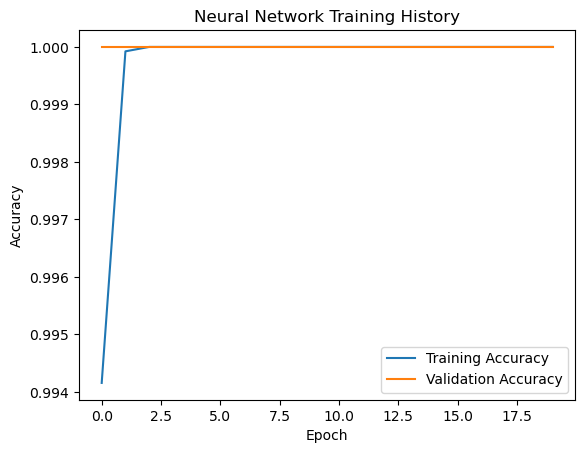

In [12]:
y_pred_nn = (model.predict(X_test) > 0.5).astype("int32")
print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn))

# Plot training history
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Neural Network Training History')
plt.show()

Based on the above code, write your own code to develop other ML or Neural network algorithms from list below.

Machine Learning Algorithms
**bold text**
Decision Tree Classifier:  https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

K-Nearest Neighbors (KNN):  https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

Logistic Regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

Naive Bayes Classifier: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html


**Deep Learning Models**
Long Short-Term Memory (LSTM): https://keras.io/api/layers/recurrent_layers/lstm/

Convolutional Neural Networks (CNN): https://keras.io/api/layers/convolution_layers/convolution1d/

Transformers (Hugging Face Transformers)

**Important: Lab-Logbbok requirement**

Provide a bar graph comparing accuracy, precicion, recall, and f-score for various AI models



Dataset Shape: (569, 30)

Training Decision Tree...
Decision Tree Results:
Accuracy: 0.9473684210526315
Precision: 0.9577464788732394
Recall: 0.9577464788732394
F1 Score: 0.9577464788732394

Training KNN...
KNN Results:
Accuracy: 0.9473684210526315
Precision: 0.9577464788732394
Recall: 0.9577464788732394
F1 Score: 0.9577464788732394

Training Logistic Regression...
Logistic Regression Results:
Accuracy: 0.9736842105263158
Precision: 0.9722222222222222
Recall: 0.9859154929577465
F1 Score: 0.9790209790209791

Training Naive Bayes...
Naive Bayes Results:
Accuracy: 0.9649122807017544
Precision: 0.958904109589041
Recall: 0.9859154929577465
F1 Score: 0.9722222222222222

Final Comparison Table:
                 Model  Accuracy  Precision    Recall  F1 Score
0        Decision Tree  0.947368   0.957746  0.957746  0.957746
1                  KNN  0.947368   0.957746  0.957746  0.957746
2  Logistic Regression  0.973684   0.972222  0.985915  0.979021
3          Naive Bayes  0.964912   0.958904  0.

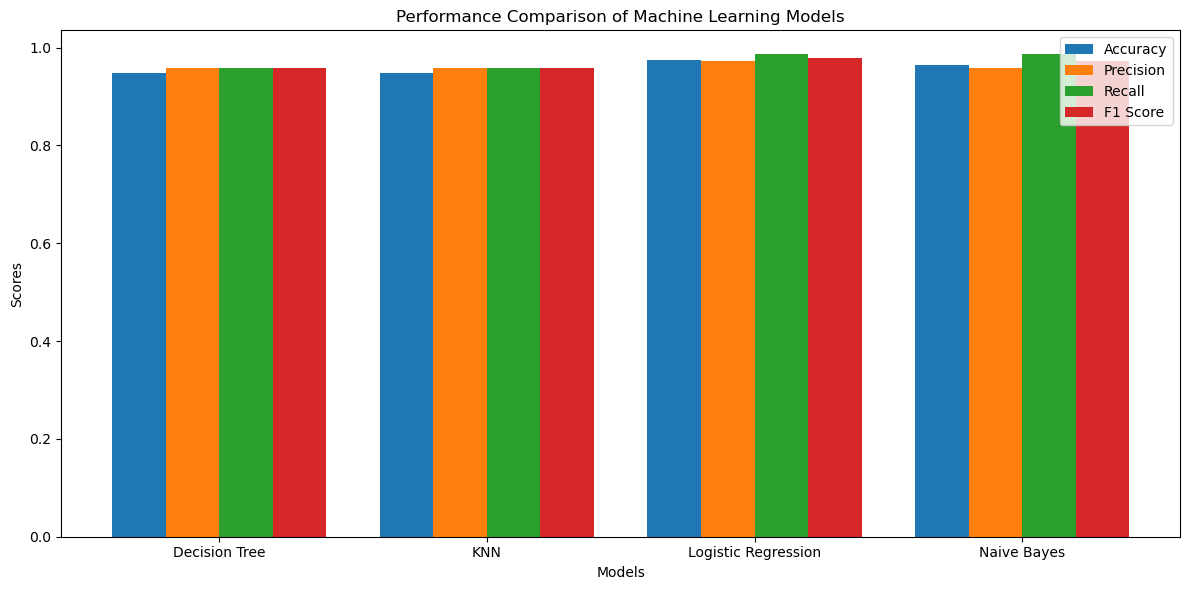

In [14]:
# IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ML Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# LOAD DATASET
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)

# Feature scaling (important for KNN, Logistic Regression)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#  INITIALIZE MODELS

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Naive Bayes": GaussianNB()
}

# TRAIN & EVALUATE MODELS

results = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": []
}

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store
    results["Model"].append(name)
    results["Accuracy"].append(acc)
    results["Precision"].append(pre)
    results["Recall"].append(rec)
    results["F1 Score"].append(f1)

    # Print results
    print(f"{name} Results:")
    print("Accuracy:", acc)
    print("Precision:", pre)
    print("Recall:", rec)
    print("F1 Score:", f1)

# RESULTS TABLE
df = pd.DataFrame(results)

print("\nFinal Comparison Table:")
print(df)


# BAR GRAPH
x = np.arange(len(df["Model"]))
width = 0.2

plt.figure(figsize=(12,6))

plt.bar(x - width, df["Accuracy"], width, label='Accuracy')
plt.bar(x, df["Precision"], width, label='Precision')
plt.bar(x + width, df["Recall"], width, label='Recall')
plt.bar(x + 2*width, df["F1 Score"], width, label='F1 Score')

plt.xlabel("Models")
plt.ylabel("Scores")
plt.title("Performance Comparison of Machine Learning Models")

plt.xticks(x + width/2, df["Model"])
plt.legend()

plt.tight_layout()
plt.show()